# Problem Set 7: Unsupervised Learning and Facial Recognition

<span style="color:red">Warning!</span> Some of the problems in this problem set require heavy computation - you are encouraged to start early so that you don't get stuck at the last minute.

# Face Recognition

Your goal for this problem set is to explore the basics of a face recognition system. Since the machine learning force is now strong with you, the prompts for this problem set are deliberately vague. Be creative - but be careful! It my be useful to start by implementing this entire problem set on a relatively small subset of all of the images first, before using the full dataset.

## 1. Data Preprocessing and  Exploration

Download the "[Faces in the Wild](http://vis-www.cs.umass.edu/lfw/)" data set from [this link](http://vis-www.cs.umass.edu/lfw/lfw-funneled.tgz) (roughly 250MB).

### 1.1. Filter out people with few images

First, display a histogram that shows the number of images per individual (you may use log-scale if you like). Which individual has the most images from your dataset? 

Now, remove all individuals for whom you have fewer than 10 images. How many individuals are you left with in the dataset?

In [234]:
import os
from skimage.io import imread

# Path to the dir containing folders of images
lfw_funneled_dir = "lfw_funneled"

# Initialize empty lists to store data
data = []
images = []
target = []
label_to_index = {}  # Dictionary to map labels to indices
index_to_label = {}  # Dictionary to map indices to labels

# Counter for assigning labels
label_counter = 0

# Iterate over folders (each folder corresponds to a target label)
for folder_name in os.listdir(lfw_funneled_dir):
    folder_path = os.path.join(lfw_funneled_dir, folder_name)
    if os.path.isdir(folder_path):
        # Iterate over images in the folder
        for filename in os.listdir(folder_path):
            image_path = os.path.join(folder_path, filename)
            
            # Read the image and flatten it
            image = imread(image_path, as_gray=False).flatten()
            # Append the flattened image to the data array
            data.append(image)
            # Append the original image to the images array
            images.append(image.reshape((250, 250, 3)))
            # Assign label to the image
            if folder_name not in label_to_index:
                label_to_index[folder_name] = label_counter
                index_to_label[label_counter] = folder_name
                label_counter += 1
            target.append(label_to_index[folder_name])

# Convert lists to arrays
data = np.array(data)
images = np.array(images)
target = np.array(target)

# Save label names along with indices
label_names = [label for label, index in label_to_index.items()]

Text(0.5, 0.98, 'Example Images from LFW Dataset')

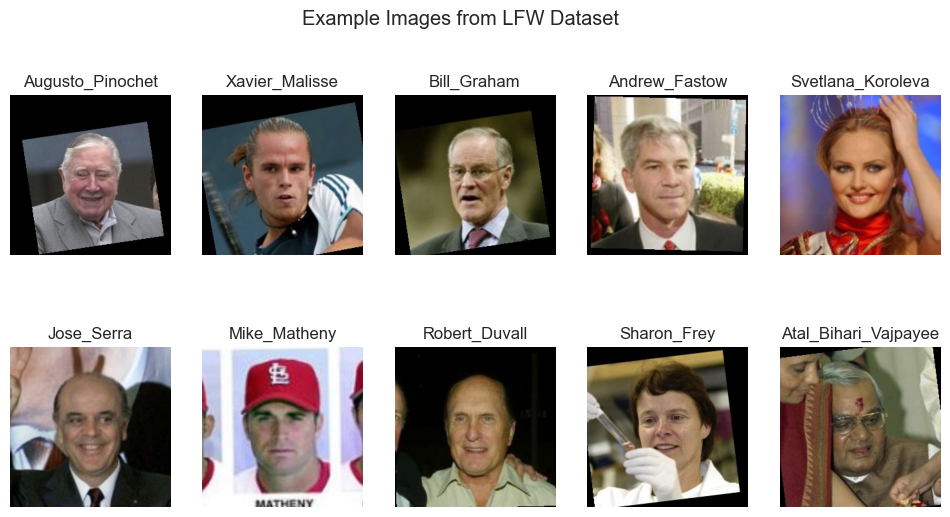

In [233]:
# Choose 10 random images 
num_images, h, w, c = images.shape
random_indices = np.random.choice(num_images, size=10, replace=False)

# Plot in a 2x5 grid
plt.figure(figsize=(12, 6))
for i, idx in enumerate(random_indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[idx], cmap='gray')
    plt.title(f'{label_names[target[idx]]}')
    plt.axis('off')
plt.suptitle('Example Images from LFW Dataset')

In [120]:
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_lfw_people

# get faces in the wild data set using sklearn 
lfw_people = fetch_lfw_people(funneled = True, color =True, resize = None, slice_ = (slice(0, 250), slice(0, 250)))

Individual with most images:  George W Bush


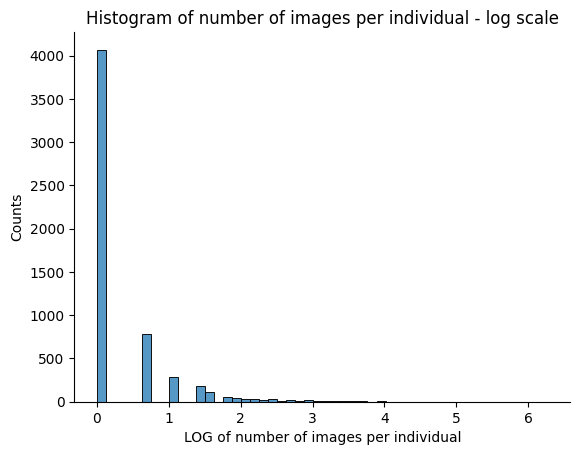

In [122]:
import seaborn as sns

# get number of indviduals and image counts for each individual 
indviduals, counts = np.unique(lfw_people.target, return_counts=True)

# plot the number of images per individual using a log scale 
sns.histplot(np.log(counts), bins = 50)
sns.despine()
plt.xlabel('LOG of number of images per individual')
plt.ylabel('Counts')
plt.title('Histogram of number of images per individual - log scale')
# Get individual with max images 
print('Individual with most images: ', lfw_people.target_names[np.argmax(counts)])


In [123]:
# calculate num of individuals 
print('Number of individuals with greater than 10 images:', len(indviduals[counts >= 10]))

Number of individuals with greater than 10 images: 158


*Your comments here*
1. Individual with most images:  Person ID: 1871 = George W Bush
2. Number of individuals with greater than 10 images: 158

 


### 1.2. Show some faces!

1. Pick 10 random images from the dataset and display them in a 2 x 5 grid.
2. This time pick 200 random images. Create a single image that shows the "average face" over this random sample -- i.e. each pixel should display the average value of that particular pixel across the random sample. 

Text(0.5, 0.98, 'Example Images from LFW Dataset')

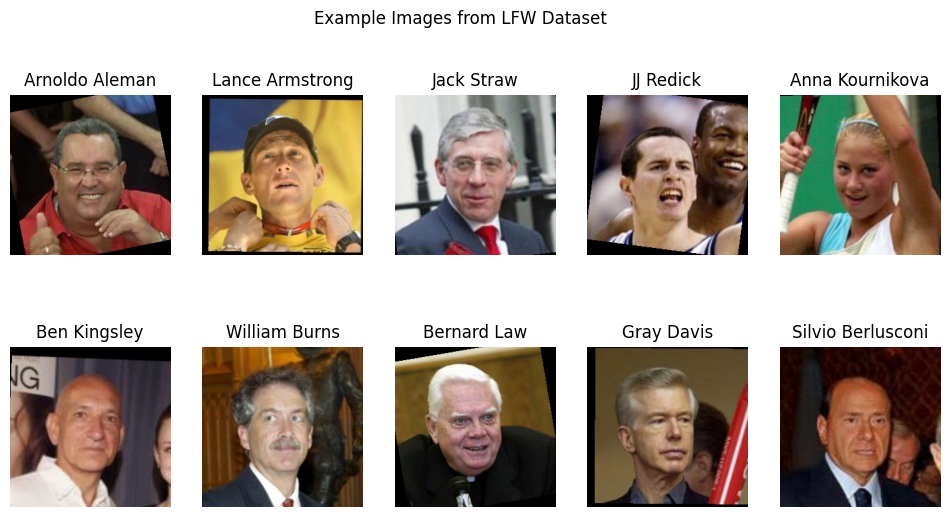

In [121]:
# Choose 10 random images 
num_images, h, w, c = lfw_people.images.shape
random_indices = np.random.choice(num_images, size=10, replace=False)

# Plot in a 2x5 grid
plt.figure(figsize=(12, 6))
for i, idx in enumerate(random_indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(lfw_people.images[idx], cmap='gray')
    plt.title(f'{lfw_people.target_names[lfw_people.target[idx]]}')
    plt.axis('off')
plt.suptitle('Example Images from LFW Dataset')

Text(0.5, 1.0, 'Average Face over 200 Random Images')

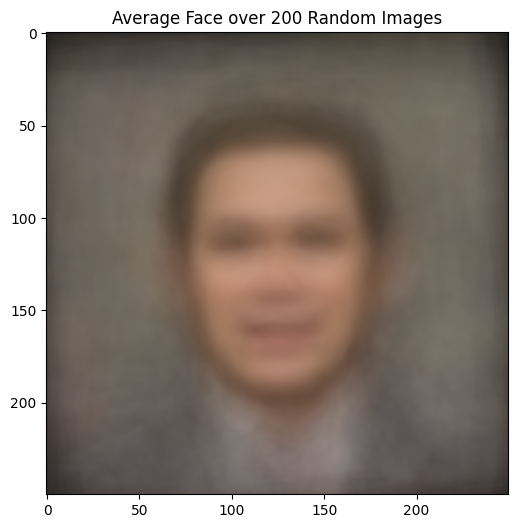

In [124]:
# 2. Ave map of 200 images 

# Choose 200 random images
random_indices_200 = np.random.choice(num_images, size=200, replace=False)
random_images = lfw_people.images[random_indices_200]

# Calculate the average face 
average_face = np.mean(random_images, axis=0)

# Plot the average face
plt.figure(figsize=(6, 6))
plt.imshow(average_face, cmap='gray')
plt.title('Average Face over 200 Random Images')


## 2. k-Means Clustering


### 2.1. Implementation

Implement the k-Means clustering algorithm that we discussed in class, using the Euclidean distance function. This will require that you define three new functions:
1. InitializeCentroids(X, k)
2. FindClosestCentroids(X, centroids)
3. ComputeCentroidMeans(X, centroids, k)

*Hint:* You may find  the [`pairwise_distances_argmin`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise_distances_argmin.html) function useful.

In [125]:
import numpy as np
from sklearn.metrics import pairwise_distances_argmin

def initialize_centroids(X, k):
    centroids_indices = np.random.choice(X.shape[0], k, replace = False) #ensure unique starting points 
    centroids = X[centroids_indices]
    return centroids

def find_closest_centroids(X, centroids):
    closest_centroids = pairwise_distances_argmin(X, centroids, metric = 'euclidean') # use euclidean distance
    return closest_centroids

def compute_centroid_means(X, closest_centroids, k):
    centroids = np.zeros((k, X.shape[1]))
    for i in range(k): # for each cluster 
        centroids[i] = np.mean(X[closest_centroids == i], axis=0) # take mean of all data points assigned to cluster 
    return centroids

def k_means(X, k, max_iters=100):
    # Initialize centroids
    centroids = initialize_centroids(X, k)
    
    for _ in range(max_iters):
        # Assign each data point to the closest centroid
        closest_centroids = find_closest_centroids(X, centroids)
        
        # Compute new centroids based on the cluster assignment mean
        new_centroids = compute_centroid_means(X, closest_centroids, k)
        
        # Check for convergence: previous centroids match newly found centroids 
        if np.allclose(new_centroids, centroids):
            break
        
        centroids = new_centroids
    
    return centroids, closest_centroids

### 2.2. Sanity check

Apply your k-Means algorithm to a toy dataset to make sure it works properly. Also create a scatterplot that shows these datapoints, colored by cluster. 

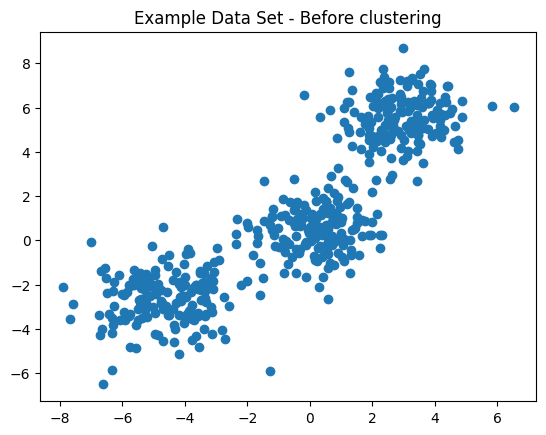

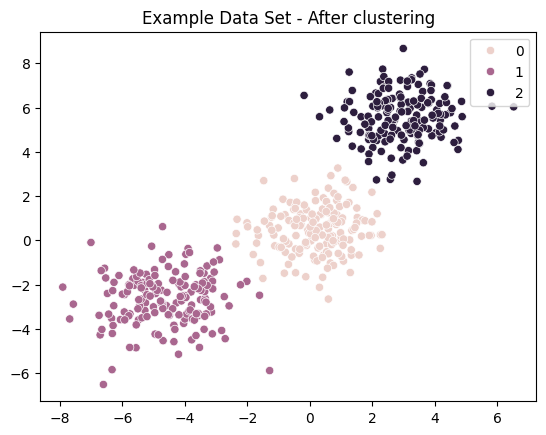

In [126]:
from sklearn import datasets 

# Toy Data Set
cmap = sns.color_palette()
X,y = datasets.make_blobs(
    n_samples=500, cluster_std=[1.25, 1, 1], random_state=1230)
plt.scatter(X[:,0], X[:,1])
plt.title('Example Data Set - Before clustering')
plt.show()

# Run k-means
k = 3 # Number of clusters
centroids, cluster_labels = k_means(X, k)

# Plot identified labels with data 
sns.scatterplot(x = X[:,0], y = X[:,1], hue= cluster_labels, )
plt.title('Example Data Set - After clustering')
plt.show()

### 2.3. Image centroids
Apply your k-Means algorithm to the images dataset, using k=10. Make sure to standardize your data first! Show a 10 x 2 grid of images where the first column contains (a) the image that represents the centroid for each of those clusters, and the second column contains (b) the closest image in the original dataset to that centroid. Use Euclidean distance. What do you notice?

*Note:* As you may notice, there are 250x250x3 = 187500 features for each image. If your k-Means algorithm is not implemented efficiently -- and even if it is -- it might take a long time for your algorithm to converge. If your computer is slow, it might even take a very long time for you to simply standardize your data. We recommend you convert your RGB images into grayscale first (using, for instance, the [`rgb2grey`](http://scikit-image.org/docs/dev/api/skimage.color.html#skimage.color.rgb2grey) function, or any other way to convert to graysacle) before standardizing.



In [193]:
lfw_people.images.shape

(13233, 250, 250, 3)

In [129]:
from sklearn.preprocessing import StandardScaler
from skimage.color import rgb2gray

# Convert RGB images to grayscale and reshape 
X_gray = rgb2gray(lfw_people.images)
X_gray = X_gray.reshape((X_gray.shape[0], -1))

# standardize images 
scaler = StandardScaler()
X_gray = scaler.fit_transform(X_gray)

# Run k-means on standardized data 
k = 10 # Number of clusters
centroids, cluster_labels = k_means(X_gray, k)

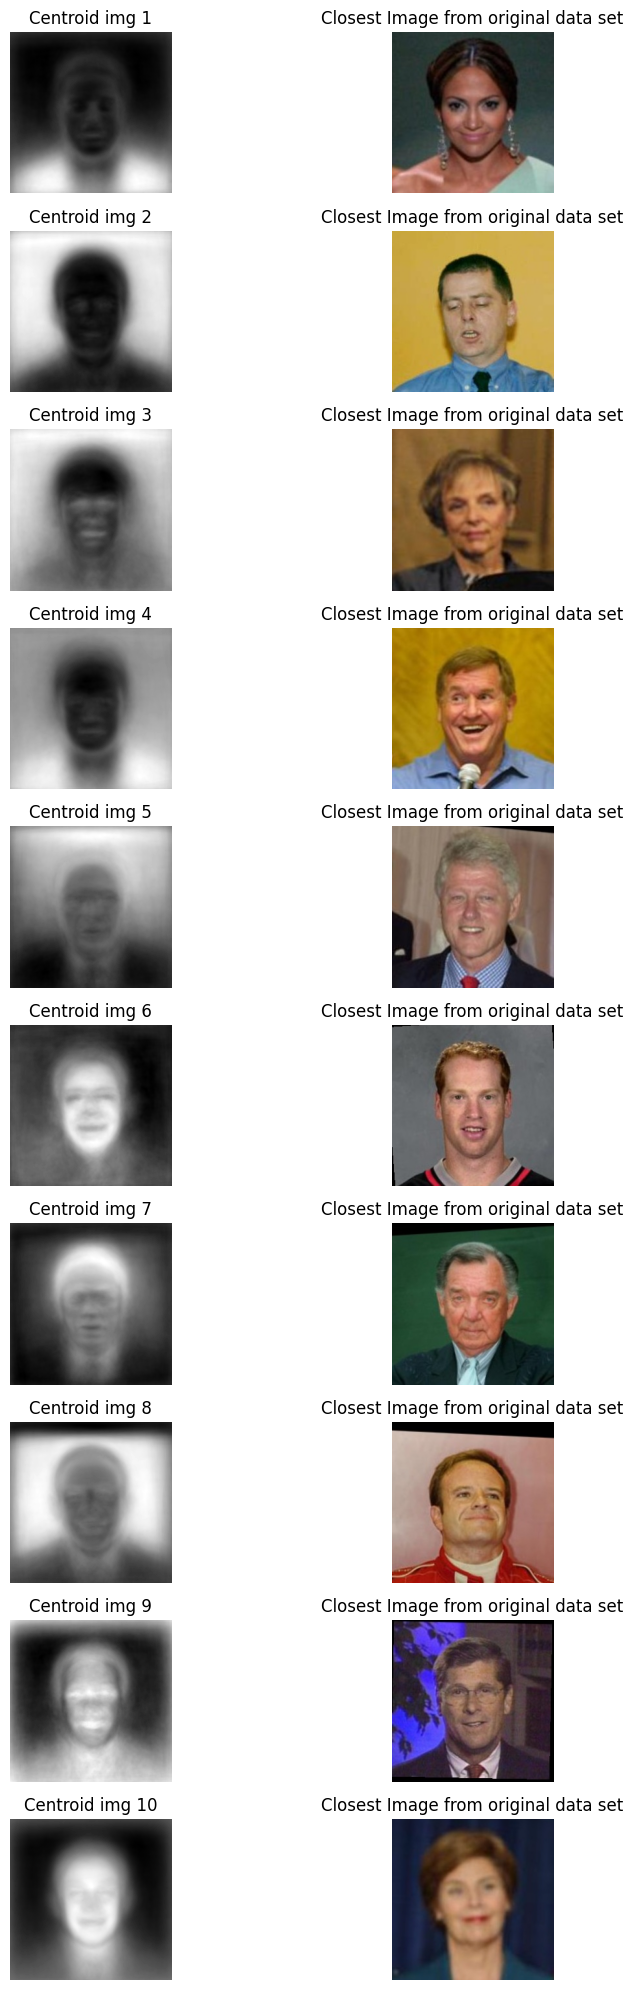

In [137]:
# Cluster Image Comparison 
fig, axes = plt.subplots(10, 2, figsize=(10, 20))
img_shape = lfw_people.images[0].shape[:2]
for i in range(k):
    # Centroid image
    centroid_image = centroids[i].reshape(img_shape)
    axes[i, 0].imshow(centroid_image, cmap='gray')
    axes[i, 0].axis('off')
    axes[i, 0].set_title(f"Centroid img {i+1}")
    
    # Closest image in original dataset
    closest_img_index = np.argmin(np.linalg.norm(X_gray - centroids[i], axis=1)) # find closest img by minimizing euclidean dist diff
    closest_image = lfw_people.images[closest_img_index]
    axes[i, 1].imshow(closest_image, cmap='gray')
    axes[i, 1].axis('off')
    axes[i, 1].set_title("Closest Image from original data set")

plt.tight_layout()
plt.show()

*Your comments here*
- I notice the centroid images differ based on whether there is a light or dark background and how well illuminated the face is ( this could also be party skin tone). The centroids also capture basic features like eyes nose and lips that differ slightly between different centroid images. The closest examples show case the difference in contrast betwwen the subject and background and also a bit the contours on the face. 

### 2.4 Classify yourself

Take a picture of yourself and scale it so that it is in a similar format to the images in the dataset. Show four images:
 1. The image of yourself.
 2. The cluster centroid closest to that image.
 3. The closest image in the dataset to that cluster centroid.
 4. The closest image in the dataset to the image of yourself.


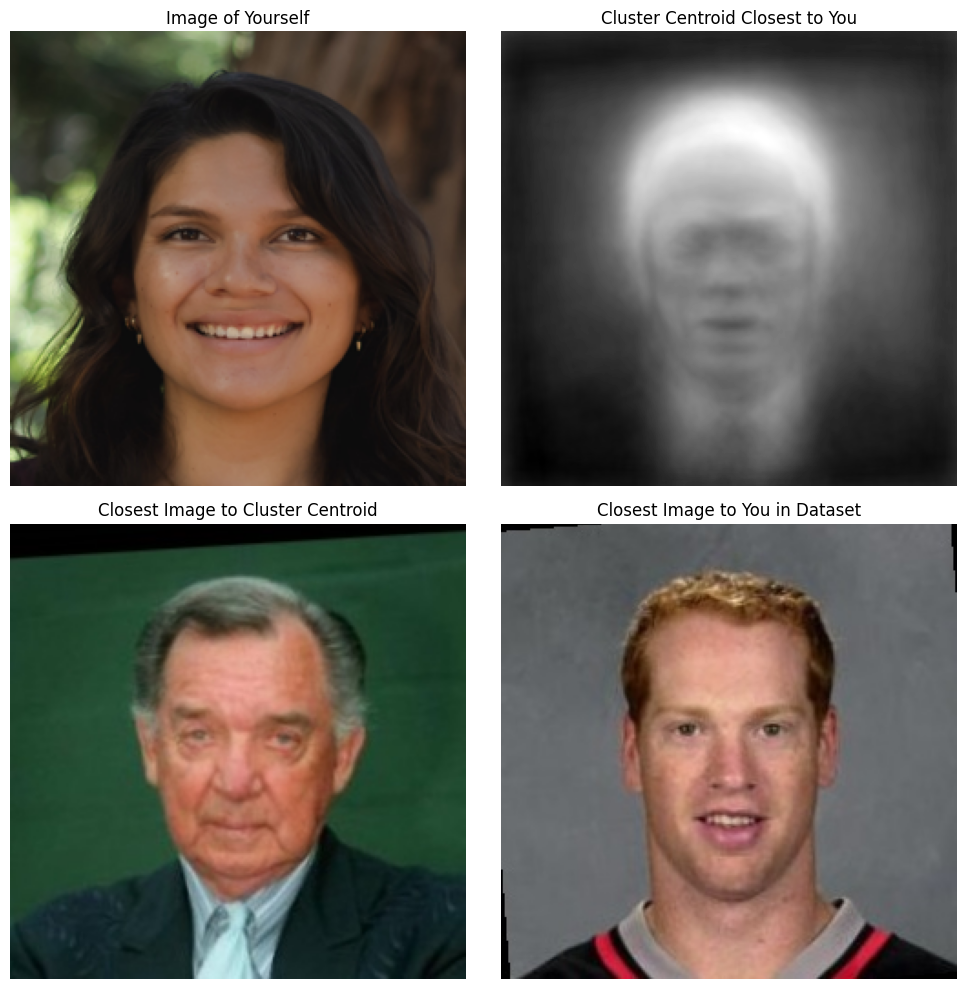

In [170]:
from PIL import Image

# 1. Image of yoursef: Read and resize  image
image = Image.open('LG_pic2.jpg')
resized_image = image.resize((250, 250))

# convert 2 greyscale and standardize img 
lg_gray = rgb2gray(resized_image)
lg_gray = lg_gray.reshape((1, lg_gray.shape[0]*lg_gray.shape[1]))
lg_gray = scaler.fit_transform(lg_gray)

# 2. Find the cluster centroid closest to the image of yourself
cluster_centroid_to_lg = np.argmin(np.linalg.norm(centroids - lg_gray[0], axis=1))

# 3. Find the closest image in the dataset to that cluster centroid
closest_image_to_cluster_centroid = np.argmin(np.linalg.norm(X_gray - centroids[cluster_centroid_to_lg], axis=1))

# 4. Find the closest image in the dataset to the image of yourself
closest_image_to_lg = np.argmin(np.linalg.norm(X_gray - lg_gray[0], axis=1))

# Plot images
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
# 1. The image of yourself.
axes[0, 0].imshow(resized_image, cmap='gray')
axes[0, 0].axis('off')
axes[0, 0].set_title("Image of Yourself")

# 2. The cluster centroid closest to that image.
centroid_image = centroids[cluster_centroid_to_lg].reshape(img_shape)
axes[0, 1].imshow(centroid_image, cmap='gray')
axes[0, 1].axis('off')
axes[0, 1].set_title("Cluster Centroid Closest to You")

# 3. The closest image in the dataset to that cluster centroid.
closest_image = lfw_people.images[closest_image_to_cluster_centroid]
axes[1, 0].imshow(closest_image, cmap='gray')
axes[1, 0].axis('off')
axes[1, 0].set_title("Closest Image to Cluster Centroid")

# 4. The closest image in the dataset to the image of yourself.
closest_image_to_lg_dataset = lfw_people.images[closest_image_to_lg]
axes[1, 1].imshow(closest_image_to_lg_dataset, cmap='gray')
axes[1, 1].axis('off')
axes[1, 1].set_title("Closest Image to You in Dataset")

plt.tight_layout()
plt.show()

### 2.5. (Extra credit): k-Means++
- In 2.1 you implemented k-Means clustering with random initialization of the centroids. In this part implement the k-Means++ version of the algorithm that uses a "smarter" initialization of the centroids in order to achieve faster convergence. Compare the number of iterations it took k-Means in 2.3 to converge with random initialization to the number of iterations it takes k-Means++. Also compare the sum of squared errors that you obtain for both methods. Use for both k=20 clusters. The following link shows the paper that proposed k-Means++.
http://ilpubs.stanford.edu:8090/778/1/2006-13.pdf

In [ ]:
# Your code here

*Your comments here*

## 3. PCA and Eigenfaces 

Ensure you are using standardized data. Then, set aside 50% of the images as "test" data and using the remaining images as "training" data.


### 3.1. How many components?

Run principal component analysis using [PCA](http://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) from sklearn on the training dataset. Create a figure showing how the amount of variance explained by your components increases as you increase the number of components from 1 to 100. How many components are required to explain 75% of the variation in your original data?

In [188]:
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

# Split into training and test sets
X_train, X_test = train_test_split(X_gray, test_size=0.5, random_state=8)

#  PCA on  training dataset
pca = PCA(n_components=100)  # Consider up to 100 components
X_train_pca = pca.fit_transform(X_train)

# Calculate cumulative explained variance
cumulative_explained_variance = np.cumsum(pca.explained_variance_ratio_)

# Find num of components req to explain 75% of variance
num_components_75 = np.argmax(cumulative_explained_variance >= 0.75) + 1

Number of components required to explain 75% of the variation: 44


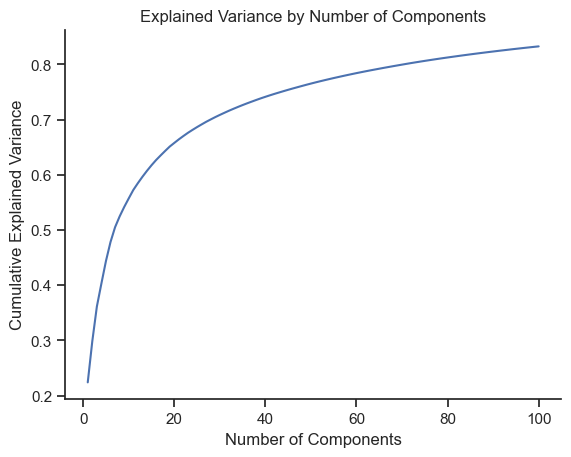

In [189]:
# Plot the explained variance for x number of components
sns.set_theme(style="ticks")
sns.lineplot(x = range(1, len(cumulative_explained_variance) + 1), y = cumulative_explained_variance)
plt.title('Explained Variance by Number of Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
sns.despine()
print(f"Number of components required to explain 75% of the variation: {num_components_75}")


*Your comments here*
- from the plot above we can get the number of components required to reach 75% variance explained and that is N = 44 components

### 3.2. The Eigenfaces

Extract the 10 first principal components (the "eigenfaces") and display them below.

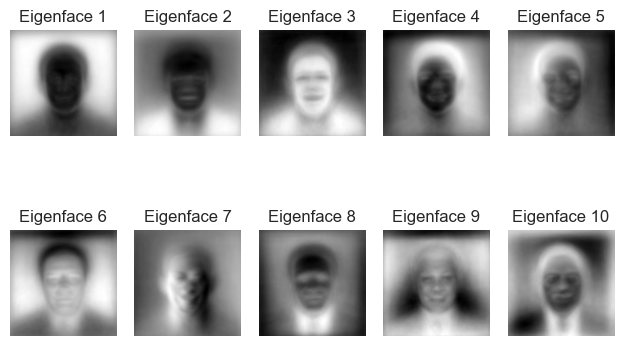

In [187]:
# select and reshape top 10 eigenfaces
eigenfaces = pca.components_[:10]
eigenface_images = eigenfaces.reshape(-1, img_shape[0], img_shape[1])

# Plot the eigenfaces
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(eigenface_images[i], cmap='gray')
    plt.title(f"Eigenface {i+1}")
    plt.axis('off')
plt.tight_layout()
plt.show()


### 3.3. Projections, clustering and PCA
 - Project all of the training and test data into the 40-dimensional space defined by the first 40 principal components.
 - Apply k-means clustering, with k=16, to the 40-dimensional projections of the training data. 
 - Display a 4 x 4 grid of images that shows what each of the 16 centroids look like after the centroid is projected back into the original-image space.

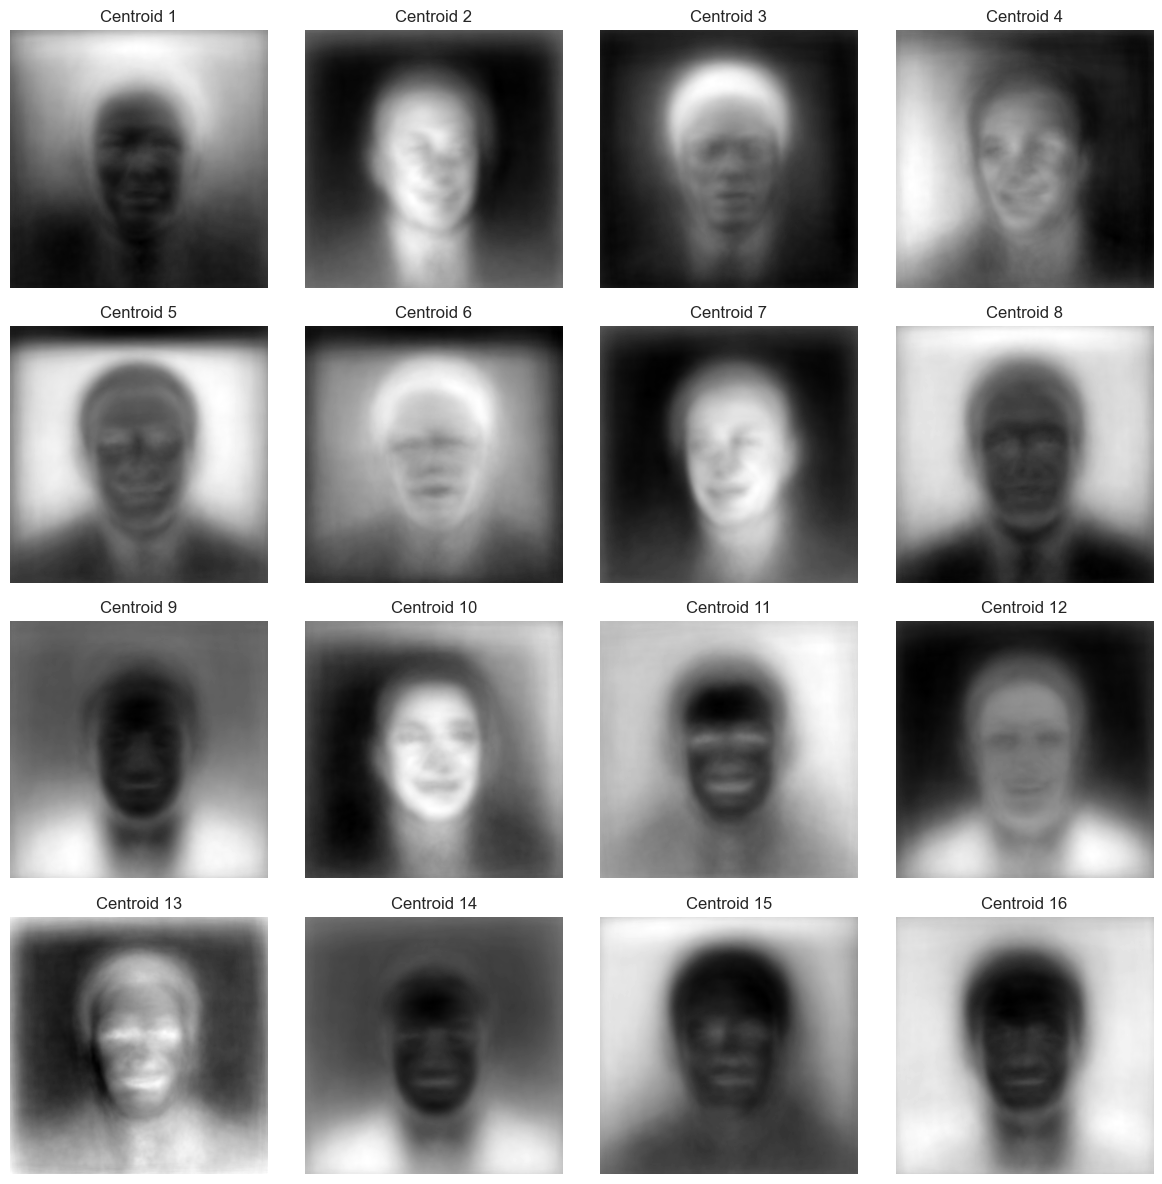

In [200]:
# Project data to first 40 component latent space
X_train_pca_40 = X_train_pca[:, :40]
X_test_pca_40 = pca.transform(X_test)[:, :40]

# Apply k-means, k = 16 to the projections of the training data
k = 16
centroids_40, _ = k_means(X_train_pca_40, k)

# Project the centroids back into the original-image space
centroids_original_space = pca.inverse_transform(np.hstack((centroids_40, np.zeros((k, 60)))))  # Use np.zeros to fill in the remaining components
centroids_original_images = centroids_original_space.reshape(-1, img_shape[0], img_shape[1])

# Display a 4x4 grid of images showing the centroids in the original-image space
plt.figure(figsize=(12, 12))
for i in range(k):
    plt.subplot(4, 4, i + 1)
    plt.imshow(centroids_original_images[i], cmap='gray')
    plt.title(f"Centroid {i+1}")
    plt.axis('off')
plt.tight_layout()
plt.show()


### 3.4. (Extra Credit): Recognition

Create a set of 10 images using (i) 8 images randomly selected from the test data, (ii)  any other non-face image you can find that has the right dimensions, and (iii) an image of yourself. Create a 10 x 5 grid of images, with one row for each of these images, and 5 columns that contain: 
1. The original image. 
2. The reconstruction of that image after it is projected onto the 40-dimensional eigenface-space and then re-projected back into the original image space. 
3. Find the nearest centroid (from 3.3) to the image, and show the reconstruction of that nearest centroid. 
4. Find the image in the training data whose 40-dimensional representation is closest to that centroid, and show the reconstruction of that image.
5. Show the original training image that was selected in above (step 4 in this list)

Post the five images corresponding to your headshot on piazza to share with the rest of the class.

In [ ]:
# Your code here